In [57]:
#Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

# Step 2 Ml processing 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder # for label encoding


## Accuracy for the Decision Tree
**Task**
Train the decision tree model using the training data. Then, calculate the accuracy of the validation set. To do so, you will need to calculate model predictions on a validation set first. Use the predict() method to get these predictions and store them in the predicted_valid variable.

Calculate accuracy and store its value in the accuracy_valid variable. Print it on the screen.

In [45]:

pre_data = pd.read_csv('/home/susan/Feature_Engineering_Sprint_9/Data/travel_insurance_us_preprocessed.csv')
print(pre_data.columns)
features =pre_data.drop('Claim', axis= 1)
target = pre_data['Claim']
X_train, X_valid, y_train, y_vaild = train_test_split( features, target, random_state= 12345, test_size= 0.25)
model = RandomForestClassifier(random_state= 12345)
model.fit(X_train,y_train)
predicted_valid = model.predict(X_valid)
accuracy_valid = accuracy_score(y_vaild,predicted_valid)
print()
print('======='*50)
print(accuracy_valid)

Index(['Unnamed: 0', 'Claim', 'Duration', 'Net Sales', 'Commission (in value)',
       'Age', 'Agency_ART', 'Agency_C2B', 'Agency_CBH', 'Agency_CCR',
       ...
       'Destination_URUGUAY', 'Destination_UZBEKISTAN', 'Destination_VANUATU',
       'Destination_VENEZUELA', 'Destination_VIET NAM',
       'Destination_VIRGIN ISLANDS, U.S.', 'Destination_ZAMBIA',
       'Destination_ZIMBABWE', 'Gender_M', 'Gender_None'],
      dtype='object', length=198)

0.9865771812080537


### `Sanity Check`
*Tasks*

1-  To count classes in the target column, use the value_counts() method. Make the count relative by using the normalize= parameter.
Save the output in the class_frequency variable and print it on the screen.
Also, use the plot() method with the kind='bar' argument to plot the counts in the form of a diagram.
 
2- In a similar way, you should analyze the class frequencies of the decision tree predictions (the predicted_valid variable). In particular, you should:
Apply the value_counts() method. Make the frequencies relative.
Save the values in the class_frequency variable. Print them on the screen.
Use the plot() method with the kind='bar' argument to plot a diagram.


3- Create a constant model: it predicts class "0" for any observation. Save its predictions in the target_pred_constant variable. Calculate the accuracy value for such a model and print it on the screen.




Claim
0    0.985136
1    0.014864
Name: proportion, dtype: float64


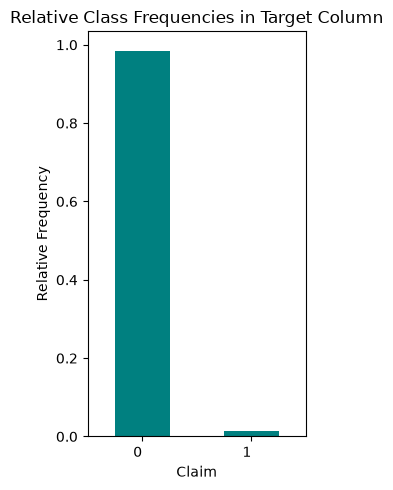

0    0.984287
1    0.015713
Name: proportion, dtype: float64


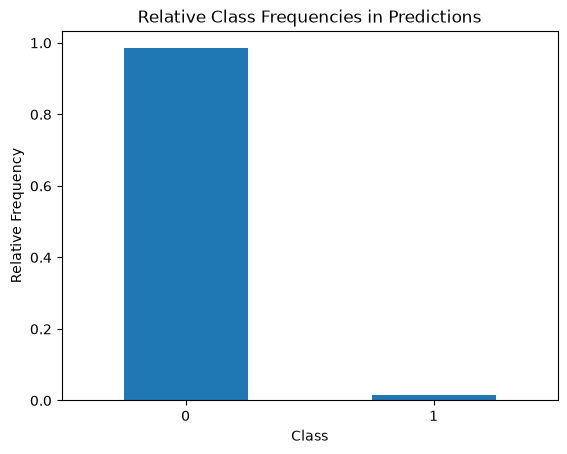

0.9851362021318595


In [46]:
class_frequency = pre_data['Claim'].value_counts(normalize= True)
print(class_frequency)

class_frequency.plot(kind = 'bar' , x= 'Claim' , y = 'class_frequency', 
                     figsize= (3, 5),
                     color= 'teal',
                     title = "Relative Class Frequencies in Target Column")
plt.xlabel('Claim')
plt.ylabel('Relative Frequency')
plt.xticks(rotation =0 , ha='right')
plt.tight_layout()
plt.show()


# 2
# Use the same split and model style as the task
features = pre_data.drop("Claim", axis=1)
target = pre_data["Claim"]

X_train, X_valid, y_train, y_valid = train_test_split(
    features, target, random_state=12345, test_size=0.25
)

model = DecisionTreeClassifier(random_state=12345)
model.fit(X_train, y_train)

predicted_valid = pd.Series(model.predict(X_valid))

# Always show both classes 0 and 1
class_frequency_pred = predicted_valid.value_counts(normalize=True).reindex([0, 1], fill_value=0)

print(class_frequency_pred)

class_frequency_pred.plot(kind="bar")
plt.xlabel("Class")
plt.ylabel("Relative Frequency")
plt.title("Relative Class Frequencies in Predictions")
plt.xticks(rotation=0)
plt.show()

# 3 # Create a fake model 
target_pred_constant = pd.Series(0, index =target.index)
accuracy_valid = accuracy_score(target, target_pred_constant)
print(accuracy_valid)





**In our task**, the True Positive answer equates to the number of insured people who:according to the model's prediction asked for compensation, AND
actually made an insurance claim.

Below you have two arrays:

* the first one called predictions contains the predictions that the model made
* another, called, target has the actual values
Your goal is to count the number of TP cases and print the results on the screen.


In [47]:
target = pd.Series([1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1])
predictions = pd.Series([1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1])

# < write code here >
condition = (target==1) & (predictions == 1)
TP = condition.sum()
print(TP)
    

5


*In our task*, the True Negative answer (TN) is the number of insured people who:

* according to the model's prediction did not request a payment,

* AND didn't actually apply for insurance compensation.

#### Count the number of TN answers just as you did in the previous task. Print the results on the screen.

In [48]:
# True Negatives
target = pd.Series([1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1])
predictions = pd.Series([1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1])

# < write code here >
condition = (target!=1) & (predictions !=1)
TN = condition.sum()
print(TN)


4


In [49]:
# False positive
target = pd.Series([1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1])
predictions = pd.Series([1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1])

# < write code here >
condition = ( target ==0)& (predictions ==1) # actual claim was = 0 but model predicted 1
FP = condition.sum()
print(FP)

3


In [50]:
# False Negative
target = pd.Series([1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1])
predictions = pd.Series([1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1])

# < write code here >
condition = ( target ==1)& (predictions ==0) # actual claim was = 1 but model predicted 0
FP = condition.sum()
print(FP)

2


**Confustion Matrix**


- Calculate the confusion matrix using the confusion_matrix() function. Import it from the sklearn.metrics module. Print the result on the screen.

_ Plot a confusion matrix for the decision tree: call the confusion_matrix() function. Print it.

In [51]:
target = pd.Series([1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1])
predictions = pd.Series([1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1])

print(confusion_matrix(target, predictions))

[[4 3]
 [2 5]]


In [54]:
features = pre_data.drop("Claim", axis=1)
target = pre_data["Claim"]

X_train, X_valid, y_train, y_valid = train_test_split(
    features, target, random_state=12345, test_size=0.25
)

model = DecisionTreeClassifier(random_state=12345)
model.fit(X_train, y_train)
predicted_vaild = model.predict(X_valid)
cm = confusion_matrix(y_valid, predicted_valid)
print(cm)




[[12309   187]
 [  157    12]]


In [56]:
recall = recall_score(y_valid , predicted_valid)
print(recall)

0.07100591715976332


**Task** 
In the sklearn.metrics module find the function that calculates precision. Import it.

This function takes correct answers and predictions. It returns observations marked as positive by the model that are actually positive. Print the results on the screen.

In [59]:
precision = precision_score(y_valid , predicted_valid)
print(precision)

0.06030150753768844


Calculate:

precision using the precision_score() function
recall using the recall_score() function
F1 score **using the formula from the lesson.
Assign the metrics' values to the precision, recall and f1 variables.

Finally, print them on the screen (already in the precode).

In [70]:
target = pd.Series([1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1])
predictions = pd.Series([1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1])

precision = precision_score(target, predictions)
recall = recall_score(target, predictions)
f1= (2*precision*recall)/(precision+recall)
print(f'Recall: {recall:.3f}')
print(f'precision: {precision:.3f}')
print(f'f1_score: {f1:.3f}')
print(f1_score(target , predictions))

print()
print('F1_scroe for DecisionTree CLassifier')
print(f1_score(y_valid, predicted_valid))

Recall: 0.714
precision: 0.625
f1_score: 0.667
0.6666666666666666

F1_scroe for DecisionTree CLassifier
0.06521739130434782
